In [3]:
import pandas as pd
import matplotlib.pyplot as plt

import numpy as np

In [4]:
df = pd.read_csv("merged_bat.csv",encoding = "utf-8")

/tmp/ipykernel_16902/3117344227.py:1: DtypeWarning: Columns (87) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("merged_bat.csv",encoding = "utf-8")


In [5]:
df.head()

,Unnamed: 0,양품,lot_id,tray_id,cell_id,dt_start,rta1_cell_no,rta1_location,hta1_location,rta2_location,...,dc3_tat,c4_tat,ocv2_tat,pg1_tat,pc1_tat,sa1_tat,socv1_tat,sa2_tat,socv2_tat,sa3_tat
0,0,1,LOT-100,TRAY-1023,CELL-10747,2024-09-01 10:01:25,10,08-08-33,03-03-25,04-06-64,...,3903.0,3489.0,118.0,291.0,291.0,53555.0,5.0,355111.0,5.0,215651.0
1,1,1,LOT-100,TRAY-1023,CELL-10748,2024-09-01 10:01:25,7,08-08-33,03-03-25,04-06-64,...,3892.0,3441.0,118.0,290.0,290.0,54095.0,4.0,355249.0,5.0,215782.0
2,2,1,LOT-100,TRAY-1023,CELL-10749,2024-09-01 10:01:25,19,08-08-33,03-03-25,04-06-64,...,3900.0,3435.0,118.0,290.0,291.0,54316.0,5.0,354928.0,6.0,215655.0
3,3,1,LOT-100,TRAY-1023,CELL-10750,2024-09-01 10:01:25,24,08-08-33,03-03-25,04-06-64,...,3890.0,3409.0,118.0,290.0,290.0,54522.0,5.0,355271.0,5.0,215550.0
4,4,1,LOT-100,TRAY-1023,CELL-10751,2024-09-01 10:01:25,17,08-08-33,03-03-25,04-06-64,...,3897.0,3411.0,118.0,290.0,290.0,54522.0,5.0,355271.0,5.0,215550.0


전체 평균 불량률 (Center Line): 0.0316
관리 상한선 (UCL): 0.0495
관리 하한선 (LCL): 0.0137


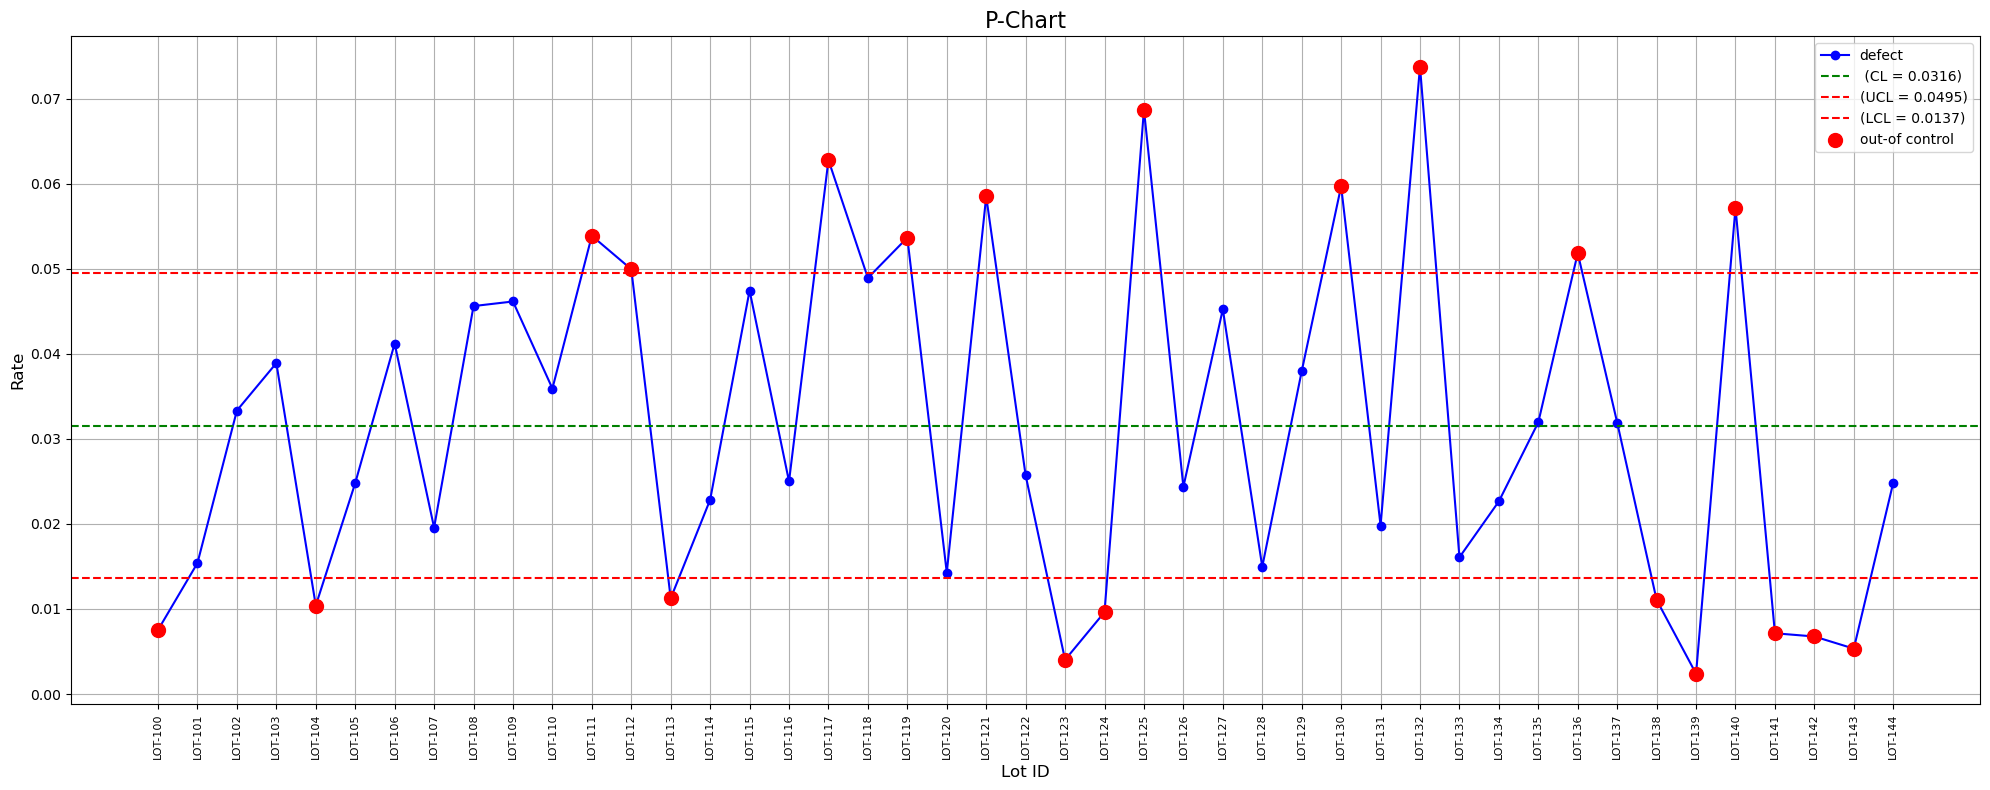


[관리 이탈 Lot 정보]
     lot_id    n  good  defects         p
0   LOT-100  929   922        7  0.007535
4   LOT-104  769   761        8  0.010403
11  LOT-111  928   878       50  0.053879
12  LOT-112  921   875       46  0.049946
13  LOT-113  889   879       10  0.011249
17  LOT-117  892   836       56  0.062780
19  LOT-119  820   776       44  0.053659
21  LOT-121  735   692       43  0.058503
23  LOT-123  746   743        3  0.004021
24  LOT-124  831   823        8  0.009627
25  LOT-125  786   732       54  0.068702
30  LOT-130  804   756       48  0.059701
32  LOT-132  949   879       70  0.073762
36  LOT-136  926   878       48  0.051836
38  LOT-138  904   894       10  0.011062
39  LOT-139  839   837        2  0.002384
40  LOT-140  857   808       49  0.057176
41  LOT-141  840   834        6  0.007143
42  LOT-142  887   881        6  0.006764
43  LOT-143  937   932        5  0.005336


In [8]:
# Lot별로 그룹화하여 전체 개수와 양품 개수를 계산합니다.
# '양품' 컬럼은 1이 양품, 0이 불량이라고 가정합니다.
lot_summary = df.groupby('lot_id')['양품'].agg(n='count', good='sum').reset_index()

# 불량 개수와 불량률(p)을 계산합니다.
lot_summary['defects'] = lot_summary['n'] - lot_summary['good']
lot_summary['p'] = lot_summary['defects'] / lot_summary['n']

# 전체 평균 불량률(p-bar)을 계산합니다. 이 값이 관리도의 중심선(CL)이 됩니다.
p_bar = lot_summary['defects'].sum() / lot_summary['n'].sum()

# 각 Lot의 크기(n)가 변하므로, 평균 Lot 크기를 사용하여 관리 한계선을 계산합니다.
n_bar = lot_summary['n'].mean()

# 관리 상한선(UCL)과 하한선(LCL)을 계산합니다.
UCL = p_bar + 3 * np.sqrt(p_bar * (1 - p_bar) / n_bar)
LCL = p_bar - 3 * np.sqrt(p_bar * (1 - p_bar) / n_bar)
LCL = max(0, LCL)  # 불량률은 0보다 작을 수 없습니다.

print(f"전체 평균 불량률 (Center Line): {p_bar:.4f}")
print(f"관리 상한선 (UCL): {UCL:.4f}")
print(f"관리 하한선 (LCL): {LCL:.4f}")

# P-Chart 시각화
plt.figure(figsize=(20, 8))
plt.plot(lot_summary['lot_id'], lot_summary['p'], marker='o', linestyle='-', color='b', label='defect')
plt.axhline(y=p_bar, color='g', linestyle='--', label=f' (CL = {p_bar:.4f})')
plt.axhline(y=UCL, color='r', linestyle='--', label=f'(UCL = {UCL:.4f})')
plt.axhline(y=LCL, color='r', linestyle='--', label=f'(LCL = {LCL:.4f})')

# 관리 범위를 벗어나는 점들을 강조 표시합니다.
out_of_control = lot_summary[(lot_summary['p'] > UCL) | (lot_summary['p'] < LCL)]
if not out_of_control.empty:
    plt.scatter(out_of_control['lot_id'], out_of_control['p'], color='red', s=100, zorder=5, label='out-of control')

plt.title('P-Chart', fontsize=16)
plt.xlabel('Lot ID', fontsize=12)
plt.ylabel('Rate', fontsize=12)
plt.xticks(rotation=90, fontsize=8)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 관리 이탈 Lot 정보 출력
if not out_of_control.empty:
    print("\n[관리 이탈 Lot 정보]")
    print(out_of_control)
else:
    print("\n모든 Lot이 관리 한계 내에 있습니다.")

--- 분석 특성: ocv1_ocv ---
T-statistic: 8.3425
P-value: 0.0000
결론: P-value가 0.05보다 작으므로, 양품과 불량품 그룹 간 'ocv1_ocv' 값의 평균에는 통계적으로 유의미한 차이가 있습니다.


/home/piai/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 48128 (\N{HANGUL SYLLABLE MIL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/piai/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/piai/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/piai/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 50577 (\N{HANGUL SYLLABLE YANG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/piai/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 54408 (\N{HANGUL SYLLABLE PUM}) missing from current font.
  fig.canvas.print_figure(bytes_i

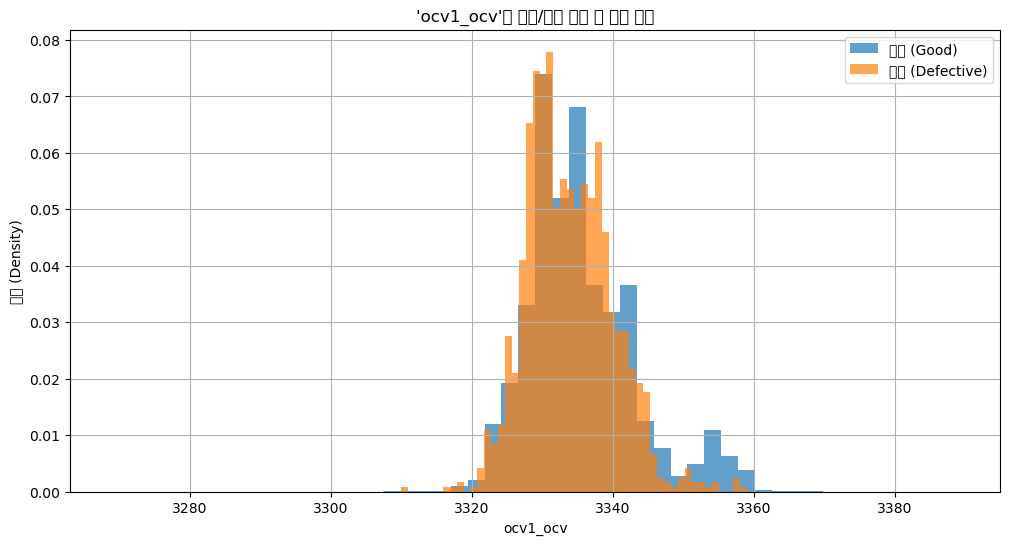



--- 분석 특성: ocv2_ocv ---
T-statistic: -7.8389
P-value: 0.0000
결론: P-value가 0.05보다 작으므로, 양품과 불량품 그룹 간 'ocv2_ocv' 값의 평균에는 통계적으로 유의미한 차이가 있습니다.


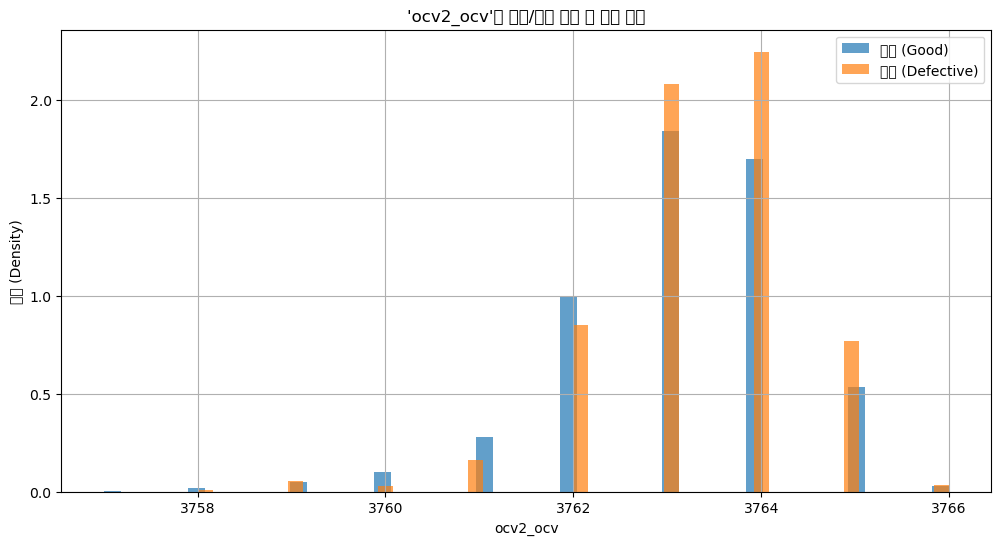



--- 분석 특성: ocv1_deltaocv ---
T-statistic: -6.5085
P-value: 0.0000
결론: P-value가 0.05보다 작으므로, 양품과 불량품 그룹 간 'ocv1_deltaocv' 값의 평균에는 통계적으로 유의미한 차이가 있습니다.


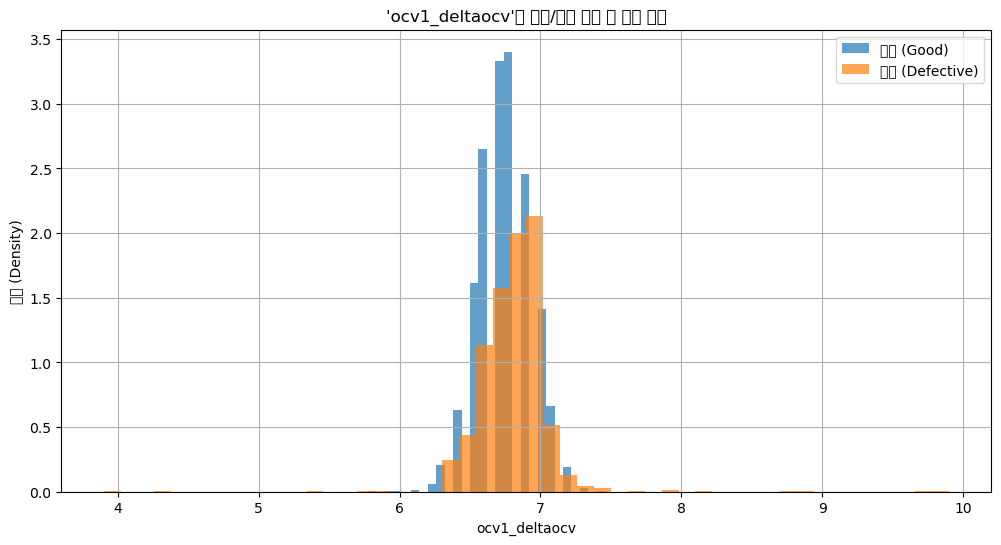



--- 분석 특성: ocv2_deltaocv ---
T-statistic: -6.2501
P-value: 0.0000
결론: P-value가 0.05보다 작으므로, 양품과 불량품 그룹 간 'ocv2_deltaocv' 값의 평균에는 통계적으로 유의미한 차이가 있습니다.


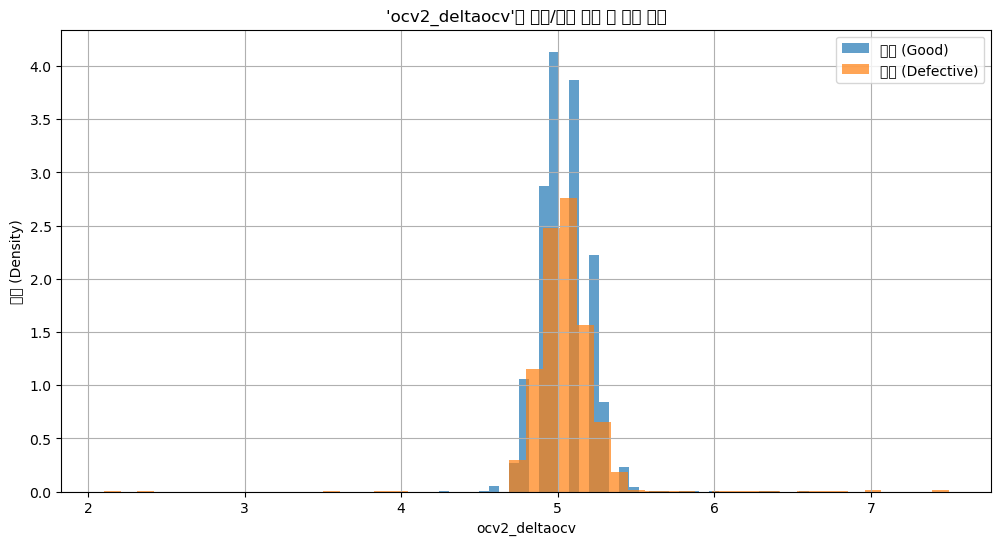



--- 분석 특성: socv1_ocv ---
T-statistic: -7.1026
P-value: 0.0000
결론: P-value가 0.05보다 작으므로, 양품과 불량품 그룹 간 'socv1_ocv' 값의 평균에는 통계적으로 유의미한 차이가 있습니다.


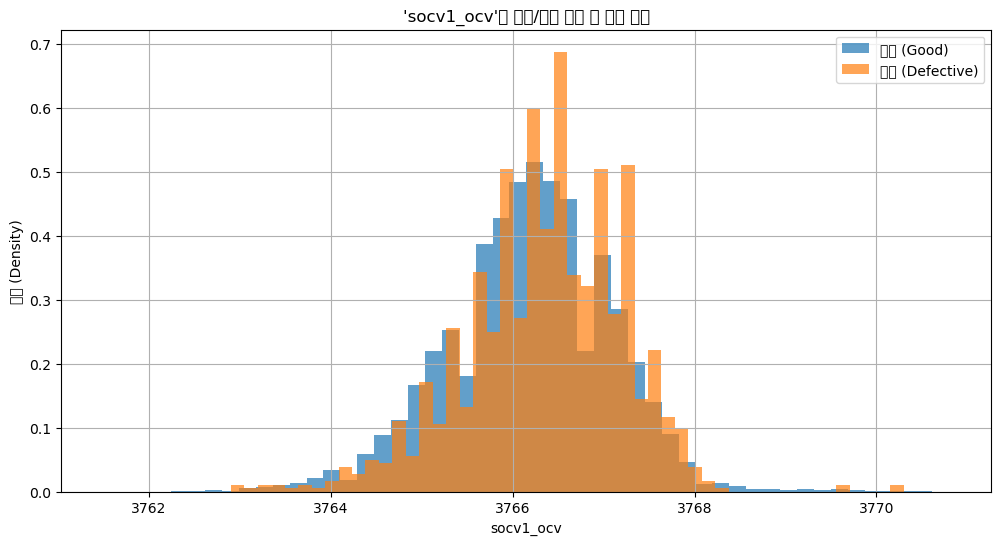



--- 분석 특성: socv2_ocv ---
T-statistic: -5.0057
P-value: 0.0000
결론: P-value가 0.05보다 작으므로, 양품과 불량품 그룹 간 'socv2_ocv' 값의 평균에는 통계적으로 유의미한 차이가 있습니다.


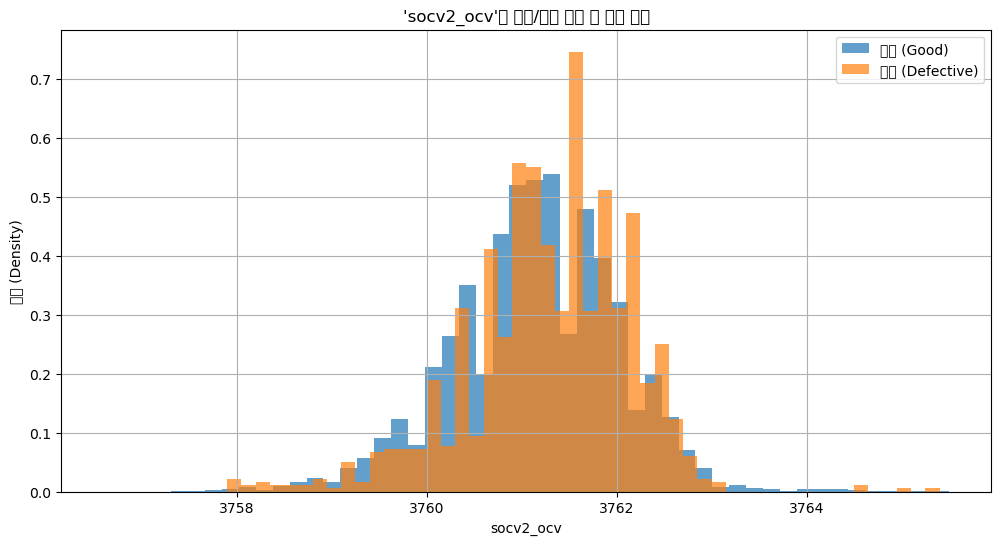



--- 분석 특성: socv3_ocv ---
T-statistic: -4.7868
P-value: 0.0000
결론: P-value가 0.05보다 작으므로, 양품과 불량품 그룹 간 'socv3_ocv' 값의 평균에는 통계적으로 유의미한 차이가 있습니다.


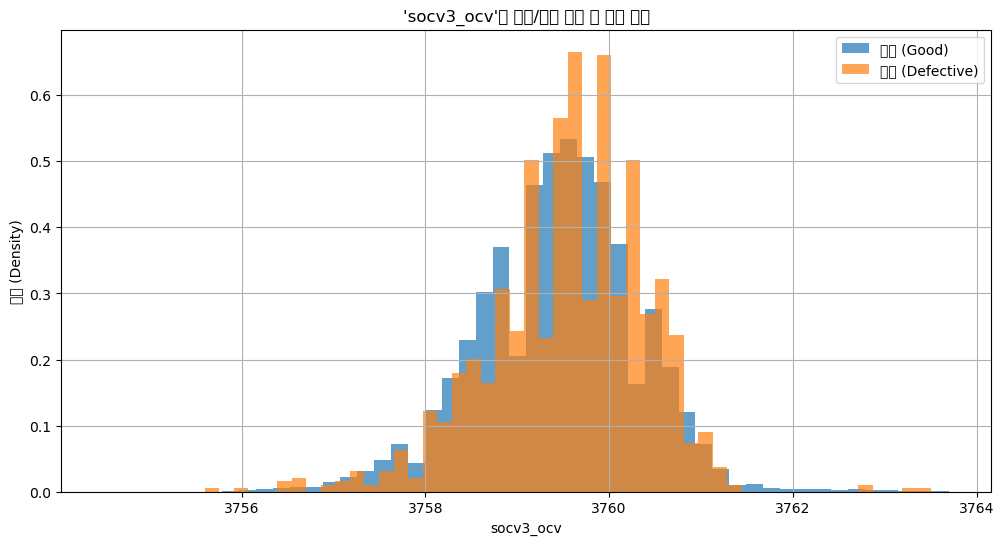

In [14]:
from scipy import stats

# 양품과 불량품 데이터프레임 분리
good_df = df[df['양품'] == 1]
defective_df = df[df['양품'] == 0]

# 분석할 OCV 관련 특성 리스트
features_to_analyze = ['ocv1_ocv', 'ocv2_ocv', 'ocv1_deltaocv', 'ocv2_deltaocv', 'socv1_ocv', 'socv2_ocv', 'socv3_ocv']

# 각 특성에 대해 T-검정 및 시각화 수행
for feature in features_to_analyze:
    # 각 그룹에서 해당 특성 데이터 추출 (NaN 값 제외)
    good_sample = good_df[feature].dropna()
    defective_sample = defective_df[feature].dropna()

    # T-검정 수행 (등분산성을 가정하지 않음 - Welch's T-test)
    t_stat, p_value = stats.ttest_ind(good_sample, defective_sample, equal_var=False)

    print(f"--- 분석 특성: {feature} ---")
    print(f"T-statistic: {t_stat:.4f}")
    print(f"P-value: {p_value:.4f}")

    # P-value를 기반으로 통계적 유의성 해석
    if p_value < 0.05:
        print(f"결론: P-value가 0.05보다 작으므로, 양품과 불량품 그룹 간 '{feature}' 값의 평균에는 통계적으로 유의미한 차이가 있습니다.")
    else:
        print(f"결론: P-value가 0.05보다 크므로, 두 그룹 간 '{feature}' 값의 평균 차이는 통계적으로 유의미하지 않습니다.")

    # 분포 시각화
    plt.figure(figsize=(12, 6))
    plt.hist(good_sample, bins=50, alpha=0.7, label='양품 (Good)', density=True)
    plt.hist(defective_sample, bins=50, alpha=0.7, label='불량 (Defective)', density=True)
    plt.title(f"'{feature}'의 양품/불량 그룹 간 분포 비교")
    plt.xlabel(feature)
    plt.ylabel("밀도 (Density)")
    plt.legend()
    plt.grid(True)
    plt.show()
    print("\n" + "="*60 + "\n")


네, 코드를 작성하는 대신 두 가지 모델의 개념에 대해 설명해 드리겠습니다. 멘토님께서 말씀하신 "셀별 분류 모델"과 "트레이별 예측 모델"은 분석의 단위를 다르게 하여 서로 다른 문제를 해결하는 접근 방식입니다.

### 1. 셀별 분류 모델 (개별 배터리 셀이 불량일까, 아닐까?)

이 모델은 개별 배터리 셀 하나하나에 초점을 맞춥니다.

*   목표: 각 셀의 공정 데이터를 보고, 이 셀이 최종적으로 '양품'이 될지 '불량'이 될지를 맞추는 것입니다.
*   모델 종류: 분류(Classification) 모델입니다. 결과가 '양품(1)' 또는 '불량(0)'처럼 두 가지 중 하나로 나오기 때문입니다.
*   입력 데이터 (Features): 개별 셀의 모든 측정값들 (`ocv1_ocv`, `c1_capa`, `pg1_imp` 등)이 입력됩니다.
*   목표 변수 (Target): `양품` 컬럼 (1 또는 0)이 정답지가 됩니다.
*   활용: 이 모델을 통해 어떤 공정 조건(예: 'OCV 값이 특정 범위보다 낮으면')에서 불량이 발생하는지 원인을 파악하고, 생산 과정에서 불량이 될 가능성이 높은 셀을 미리 선별할 수 있습니다.

---

### 2. 트레이별 예측 모델 (특정 트레이의 불량률은 얼마나 될까?)

이 모델은 셀의 그룹인 트레이(Tray) 단위에 초점을 맞춥니다.

*   목표: 특정 트레이에 속한 셀들의 전체적인 공정 데이터 평균이나 표준편차 등을 보고, 해당 트레이의 최종 불량률(%)이 얼마나 될지를 예측하는 것입니다.
*   모델 종류: 예측(Prediction) 또는 회귀(Regression) 모델입니다. '불량률 5%', '불량률 1.2%'처럼 연속적인 숫자 값을 예측하기 때문입니다.
*   입력 데이터 (Features): 트레이별로 집계된 통계 데이터가 입력됩니다. 예를 들어, 'TRAY-1023의 평균 용량(c1_capa_avg)', 'TRAY-1023의 저항 표준편차(pg1_imp_std)' 등이 사용됩니다. (CELL INDEX 6에서 이미 이런 데이터를 계산하셨습니다.)
*   목표 변수 (Target): 트레이별 불량률 (`defect_rate`)이 정답지가 됩니다.
*   활용: 이 모델을 통해 어떤 트레이의 공정이 불안정하고 불량률이 높을지 미리 예측할 수 있습니다. 예를 들어, '트레이 내 셀들의 용량 편차가 크면 불량률이 높아진다'와 같은 패턴을 발견하고, 해당 트레이의 공정 환경을 점검하는 데 활용할 수 있습니다.

### 요약

*   셀별 분류 모델: 나무 하나하나를 보고 '이 나무는 병들었다/건강하다'를 판단합니다.
*   트레이별 예측 모델: 숲 전체를 보고 '이 숲의 병든 나무 비율은 O%일 것이다'를 예측합니다.

이 두 가지 모델을 만들면, 미시적인 관점(개별 셀)과 거시적인 관점(장비 단위인 트레이) 모두에서 불량의 원인을 파악하고 공정을 개선할 수 있습니다.


네, 아주 좋은 질문입니다. 두 모델은 별개의 모델이지만, 함께 사용하여 시너지를 내는 통합적인 불량률 감소 프로세스를 만들 수 있습니다. 각 모델이 서로 다른 단계에서 역할을 수행하며, 다음과 같은 흐름으로 공정을 개선하고 불량률을 줄일 수 있습니다.

---

### 1단계: 위험 트레이 조기 경보 (트레이별 예측 모델 활용)

*   무엇을 하나요? 생산이 진행 중인 각 트레이의 공정 데이터(평균, 표준편차 등)를 트레이별 예측 모델에 입력합니다.
*   결과: 모델은 해당 트레이의 예상 불량률을 예측합니다. 예를 들어, "TRAY-2055의 예상 불량률은 8.5%입니다"와 같은 결과를 얻습니다.
*   액션: 예측된 불량률이 설정된 임계값(예: 5%)을 초과하는 트레이를 '고위험군'으로 분류하고 집중 관리 대상으로 선정합니다. 이는 마치 건강검진에서 '주의'나 '위험' 판정을 내리는 것과 같습니다.

### 2단계: 불량 원인 분석 및 핵심 인자 규명 (셀별 분류 모델 활용)

*   무엇을 하나요? 1단계에서 '고위험군'으로 분류된 트레이에 속한 개별 셀들의 데이터를 셀별 분류 모델에 입력합니다.
*   결과:
    1.  개별 셀 불량 예측: 트레이 내에서 어떤 셀이 불량이 될 확률이 높은지 정확히 집어냅니다.
    2.  핵심 원인(Feature) 도출: 모델의 '특성 중요도(Feature Importance)'와 같은 분석을 통해 불량 판정에 가장 큰 영향을 미친 공정 변수가 무엇인지 알아냅니다. (예: 'c1_capa 값이 낮아서', 'pg1_imp 값이 비정상적으로 높아서' 등)
*   액션: 불량의 원인이 되는 핵심 공정 변수(Key Parameter)를 파악합니다.

### 3단계: 공정 개선 조치 실행

*   무엇을 하나요? 2단계에서 파악한 핵심 원인을 바탕으로 실제 공정에 대한 개선 조치를 취합니다.
*   예시:
    *   만약 'pg1_imp (저항) 값의 편차'가 불량의 주요 원인으로 지목되었다면, 해당 트레이가 사용된 저항 측정 장비의 캘리브레이션을 점검하거나, 공정 환경(온도, 습도 등)을 안정화시킵니다.
    *   만약 'c1_capa (용량) 값이 특정 값 이하'인 셀들이 문제였다면, 충전 공정의 전류나 시간 설정을 미세 조정합니다.
*   단기적 조치: 셀별 모델이 불량으로 예측한 셀을 후속 공정에서 미리 제외하여 완제품의 불량률을 즉각적으로 낮출 수도 있습니다.

### 4단계: 개선 효과 검증 및 모델 업데이트 (피드백 루프)

*   무엇을 하나요? 공정 개선 조치 이후 생산된 데이터로 다시 1단계부터 반복합니다.
*   결과: 개선 조치가 효과가 있었다면, 트레이별 예측 모델이 예측하는 불량률이 전반적으로 낮아질 것입니다.
*   액션: 지속적으로 새로운 데이터를 수집하고, 이 데이터를 사용하여 두 모델을 주기적으로 재학습(Re-training)시킵니다. 이를 통해 공정의 최신 상태를 반영하는 더 정확한 모델로 유지하며, 지속적인 개선 사이클을 만듭니다.

### 요약: 두 모델의 협력 관계

*   트레이별 모델 (거시적 접근): "어디에 문제가 있는가?" (문제가 발생한 '숲' 찾기)
*   셀별 모델 (미시적 접근): "무엇이 문제인가?" (숲 속의 '병든 나무'와 그 '병의 원인' 찾기)

이처럼 두 모델을 단계적으로 연계하여 사용하면, 문제 발생을 조기에 감지하고, 근본 원인을 과학적으로 분석하여, 데이터 기반의 정확한 공정 개선을 이룰 수 있습니다. 이것이 바로 불량률을 체계적으로 줄여나가는 과정입니다.